# Bias-Variance Tradeoff: A Comprehensive Guide

The Bias-Variance Tradeoff is one of the most fundamental concepts in machine learning. It explains the relationship between model complexity, underfitting, and overfitting — and ultimately determines how well a model generalizes to new data.

In this notebook, we'll cover:
1. What is Bias and Variance?
2. The Tradeoff and the total prediction error
3. Visualizing underfitting and overfitting
4. Detecting and fixing overfitting/underfitting
5. Learning curves as a diagnostic tool

# Simple Explanation: What Does the Code Below Do?

Imagine you're trying to hit a target:
- **High Bias, Low Variance**: Arrows cluster away from the bullseye consistently. You're consistently wrong (underfitting — too simple a model).
- **Low Bias, High Variance**: Arrows are scattered all over the target randomly. You're sometimes right, sometimes very wrong (overfitting — too complex a model).
- **Low Bias, Low Variance**: Arrows cluster close to the bullseye. This is the goal!

Mathematical view:
**Total Error = Bias² + Variance + Irreducible Noise**

- **Bias**: Error from wrong assumptions (model is too simple). Underfitting.
- **Variance**: Error from sensitivity to training data (model is too complex). Overfitting.
- **Irreducible Noise**: Error from randomness in data that can't be reduced.

Here's what the code does:
1. Demonstrates high-bias (linear model on nonlinear data) and high-variance (overfit polynomial).
2. Shows learning curves to diagnose which problem you have.
3. Shows strategies to fix both underfitting and overfitting.

In short: The perfect model balances complexity — not too simple, not too complex!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment created at ml_env
Required libraries installed.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import learning_curve, train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Visualizing Bias vs. Variance: Polynomial Regression Example

We generate a sinusoidal curve with noise.
- Degree 1 polynomial → **High Bias** (underfitting)
- Degree 4 polynomial → **Good Balance**
- Degree 15 polynomial → **High Variance** (overfitting)

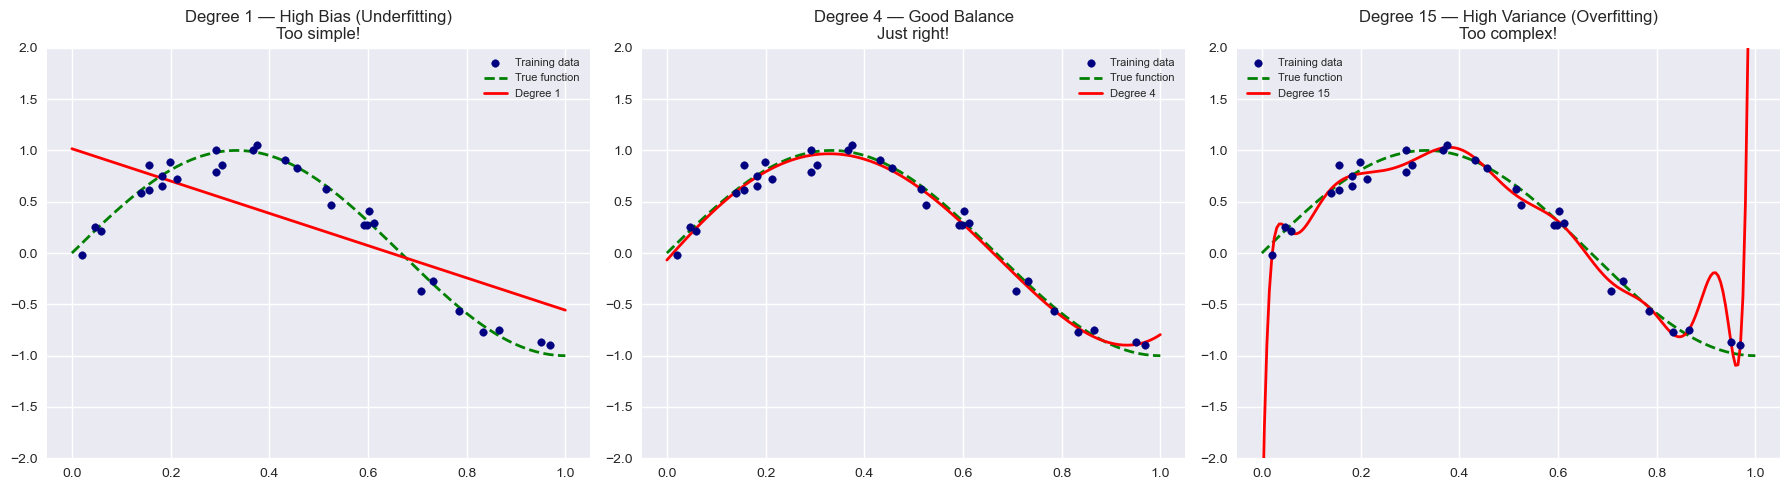

In [3]:
np.random.seed(42)

# True function: sin(1.5*pi*x)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.sin(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1

X_plot = np.linspace(0, 1, 200)
y_true = np.sin(1.5 * np.pi * X_plot)

degrees = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, degree in zip(axes, degrees):
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])
    poly_model.fit(X.reshape(-1, 1), y)
    y_pred_plot = poly_model.predict(X_plot.reshape(-1, 1))
    y_pred_train = poly_model.predict(X.reshape(-1, 1))

    train_mse = mean_squared_error(y, y_pred_train)
    
    ax.scatter(X, y, color='navy', s=30, label='Training data', zorder=5)
    ax.plot(X_plot, y_true, color='green', linewidth=2, label='True function', linestyle='--')
    ax.plot(X_plot, y_pred_plot, color='red', linewidth=2, label=f'Degree {degree}')
    ax.set_ylim(-2, 2)
    ax.set_title(f'Polynomial Degree = {degree}\nTrain MSE = {train_mse:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True)

axes[0].set_title('Degree 1 — High Bias (Underfitting)\nToo simple!')
axes[1].set_title('Degree 4 — Good Balance\nJust right!')
axes[2].set_title('Degree 15 — High Variance (Overfitting)\nToo complex!')

plt.tight_layout()
plt.show()

# 3. Learning Curves — The Best Diagnostic Tool

Learning curves plot training score and validation score vs. training set size.
- **High Bias**: Both train and validation curves plateau at a low score and the gap is small.
- **High Variance**: Large gap between train (high) and validation (low) curves.

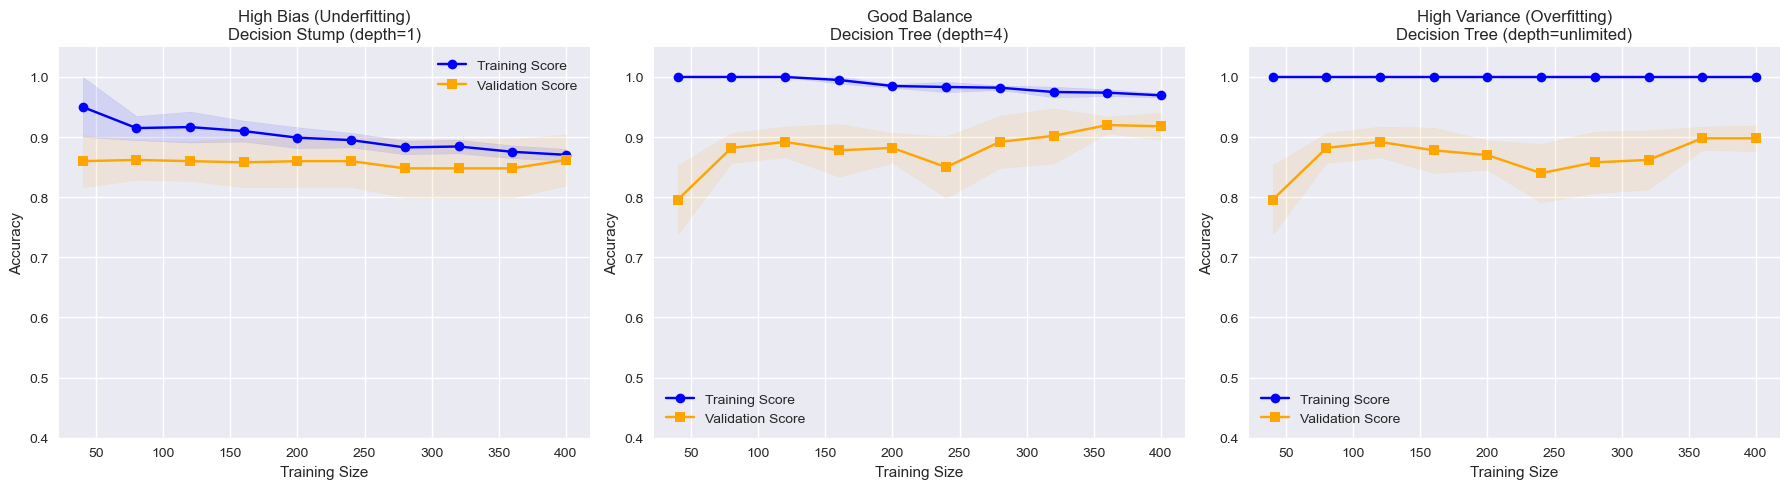

In [4]:
X_cls, y_cls = make_classification(n_samples=500, n_features=20, n_informative=3, 
                                   n_redundant=2, random_state=42)

def plot_learning_curve(model, X, y, ax, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', label='Training Score', color='blue')
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    ax.plot(train_sizes, val_mean, 's-', label='Validation Score', color='orange')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='orange')
    
    ax.set_title(title)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0.4, 1.05)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# High Bias: simple model (depth=1 decision tree — stump)
plot_learning_curve(DecisionTreeClassifier(max_depth=1, random_state=42), X_cls, y_cls, 
                    axes[0], 'High Bias (Underfitting)\nDecision Stump (depth=1)')

# Good Balance: moderate depth
plot_learning_curve(DecisionTreeClassifier(max_depth=4, random_state=42), X_cls, y_cls,
                    axes[1], 'Good Balance\nDecision Tree (depth=4)')

# High Variance: very deep tree
plot_learning_curve(DecisionTreeClassifier(max_depth=None, random_state=42), X_cls, y_cls,
                    axes[2], 'High Variance (Overfitting)\nDecision Tree (depth=unlimited)')

plt.tight_layout()
plt.show()

# 4. Using Scikit-learn — Bias-Variance Decomposition

We estimate bias and variance empirically by training on many different random subsets.

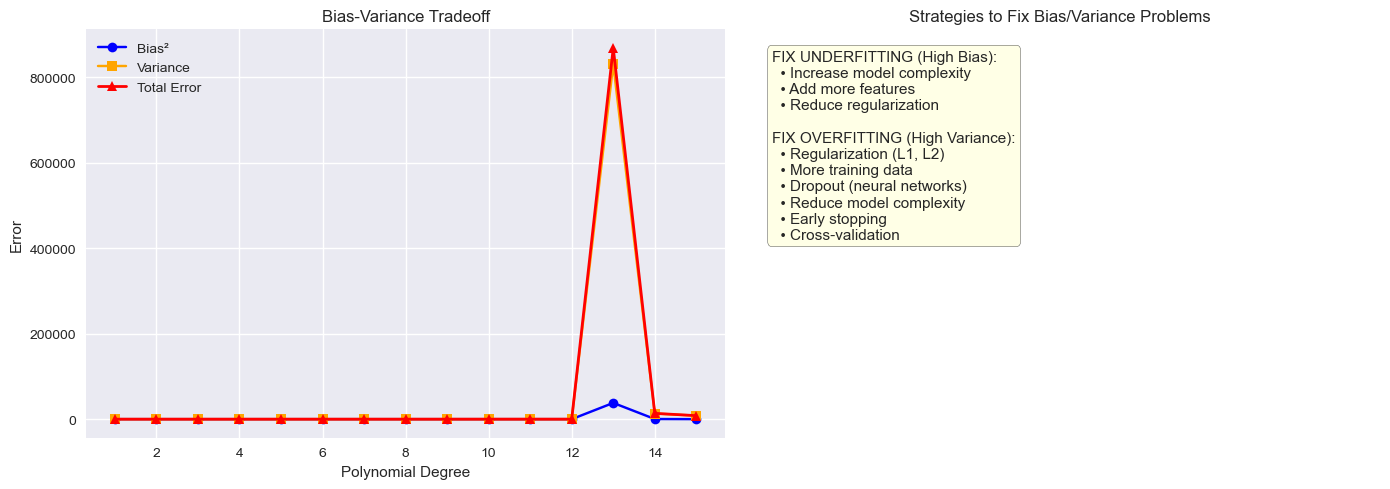

Optimal polynomial degree: 4

Key Insights:
- As complexity increases, bias decreases but variance increases.
- Total error is minimized at the sweet spot.
- Learning curves are the best way to diagnose which problem you have.


In [5]:
# Empirical bias-variance for different polynomial degrees
degrees_range = range(1, 16)
n_experiments = 30
X_all = np.sort(np.random.rand(100))
y_all = np.sin(1.5 * np.pi * X_all) + np.random.randn(100) * 0.1
X_test_bv = np.linspace(0, 1, 50).reshape(-1, 1)
y_test_bv = np.sin(1.5 * np.pi * X_test_bv.flatten())

bias2_list, var_list, total_list = [], [], []

for degree in degrees_range:
    predictions = []
    for _ in range(n_experiments):
        # Sample training subset
        idx = np.random.choice(100, size=30, replace=False)
        X_exp, y_exp = X_all[idx].reshape(-1, 1), y_all[idx]
        
        pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)), 
                         ('lr', LinearRegression())])
        pipe.fit(X_exp, y_exp)
        predictions.append(pipe.predict(X_test_bv))
    
    predictions = np.array(predictions)  # (n_experiments, n_test)
    avg_pred = predictions.mean(axis=0)
    bias2 = np.mean((avg_pred - y_test_bv) ** 2)
    var = np.mean(predictions.var(axis=0))
    bias2_list.append(bias2)
    var_list.append(var)
    total_list.append(bias2 + var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees_range, bias2_list, marker='o', label='Bias²', color='blue')
axes[0].plot(degrees_range, var_list, marker='s', label='Variance', color='orange')
axes[0].plot(degrees_range, total_list, marker='^', label='Total Error', color='red', linewidth=2)
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Error')
axes[0].set_title('Bias-Variance Tradeoff')
axes[0].legend()
axes[0].grid(True)

strategies_text = (
    'FIX UNDERFITTING (High Bias):\n'
    '  • Increase model complexity\n'
    '  • Add more features\n'
    '  • Reduce regularization\n\n'
    'FIX OVERFITTING (High Variance):\n'
    '  • Regularization (L1, L2)\n'
    '  • More training data\n'
    '  • Dropout (neural networks)\n'
    '  • Reduce model complexity\n'
    '  • Early stopping\n'
    '  • Cross-validation'
)
axes[1].text(0.05, 0.95, strategies_text, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].axis('off')
axes[1].set_title('Strategies to Fix Bias/Variance Problems')

plt.tight_layout()
plt.show()

optimal_degree = degrees_range[np.argmin(total_list)]
print(f'Optimal polynomial degree: {optimal_degree}')
print('\nKey Insights:')
print('- As complexity increases, bias decreases but variance increases.')
print('- Total error is minimized at the sweet spot.')
print('- Learning curves are the best way to diagnose which problem you have.')

# Conclusions and Key Takeaways
The Bias-Variance Tradeoff is a fundamental concept in machine learning that describes the relationship between a model's complexity, the training error, and the test error. The goal is to reach a sweet spot that minimizes both bias (underfitting) and variance (overfitting).
- **High Bias** leads to underfitting: The model is too simple and misses the underlying patterns.
- **High Variance** leads to overfitting: The model is too complex and captures the noise in the training data along with the pattern.
- **Optimal Complexity**: The objective is to design a model with the right level of complexity to achieve the lowest possible generalization error.

# Pros and Cons
**Pros of Understanding the Tradeoff:**
- Guides the choice of algorithms and model complexity.
- Helps diagnose poor model performance.
- Inform decisions on whether to gather more data, add features, or regularize.

**Cons/Challenges:**
- In practice, it's rarely possible to perfectly measure bias and variance separately without knowing the true underlying process (which we never do).
- Balancing them can be computationally expensive as it requires extensive hyperparameter tuning.

# 15 Interview Questions and Answers

1. **What is the bias-variance tradeoff?**
   *Answer*: It's the property of models where a model with a lower bias in parameter estimation has a higher variance of the parameter estimates across samples, and vice versa. It's the conflict in trying to minimize these two sources of error that prevent supervised learning algorithms from generalizing beyond their training set.

2. **What does high bias mean in a ML model?**
   *Answer*: High bias means the model makes strong assumptions about the form of the target function. It often results in underfitting, paying very little attention to training data and oversimplifying the model.

3. **What does high variance mean?**
   *Answer*: High variance means the model pays a lot of attention to training data and does not generalize well on the data it hasn't seen before. Such models perform very well on training data but have high error rates on test data.

4. **Give an example of a high bias model.**
   *Answer*: Linear regression models often have high bias if the underlying data has a complex, non-linear relationship (underfitting).

5. **Give an example of a high variance model.**
   *Answer*: Unpruned Decision Trees and k-Nearest Neighbors with a small k.

6. **How can you reduce high bias?**
   *Answer*: Increase model complexity (e.g., use a more advanced algorithm like Random Forest instead of Linear Regression), add polynomial features, or decrease regularization.

7. **How can you reduce high variance?**
   *Answer*: Use more training data, reduce model complexity (e.g., limit depth of decision tree), apply feature selection/dimensionality reduction, or increase regularization.

8. **What is irreducible error?**
   *Answer*: The error introduced by the noise in the problem itself, which cannot be reduced by any model regardless of how good it is. 

9. **Can a model have both low bias and low variance?**
   *Answer*: Yes, that is the ultimate goal. Ensemble methods like Random Forest attempt to achieve this by combining multiple high variance models to reduce overall variance without significantly increasing bias.

10. **How does adding more training data affect bias and variance?**
    *Answer*: It typically decreases variance because the model gets a better estimate of the underlying distribution, but it generally does not decrease bias unless it introduces more diverse representative cases.

11. **How do ensemble methods help with the tradeoff?**
    *Answer*: Bagging (e.g., Random Forest) reduces variance by averaging predictions of multiple models. Boosting (e.g., Gradient Boosting) sequentially reduces bias by focusing on previous errors, while also somewhat managing variance.

12. **What happens to bias and variance as k increases in k-NN?**
    *Answer*: As k increases, the model becomes smoother and simpler. Thus, bias increases and variance decreases.

13. **How do learning curves help in diagnosing bias or variance?**
    *Answer*: A model with high bias will show training and validation errors plateauing quickly at a high level. A model with high variance will show a large gap between a low training error and a high validation error.

14. **What is the mathematical formulation of total error?**
    *Answer*: Total Error = Bias² + Variance + Irreducible Error.

15. **Why can't we just find a model with zero bias and zero variance?**
    *Answer*: Because the more perfectly you try to fit the training data (zero bias), the more sensitive the model becomes to the noise specific to that training data (higher variance on unseen data).
